# Langevin Algorithm Comparison — Titanic

Same protocol as the breast-cancer and MAGIC notebooks: common initialization,
`k = 0` anchored at the starting accuracy, one gradient evaluation per
iteration, vectorized gradient, two overdamped baselines.

**The dominant fact about this dataset is its size.** 891 passengers, 179 in the
test split, so **one test point is 0.56% accuracy**. Any margin below ~0.006 is
smaller than a single passenger switching class. With enough seeds almost any
difference becomes "statistically significant", so this notebook reports every
margin twice — as a p-value, and in units of one test point. The second is the
one to trust.

**Preprocessing.** Titanic needs real feature engineering, unlike the other two:
Age is missing for 177 passengers, Embarked for 2, Cabin for 687. The 11
features are Pclass (2 dummies), Sex, Age (median-imputed) plus an
`Age_missing` indicator, SibSp, Parch, `log1p(Fare)`, Embarked (2 dummies), and
`Cabin_known`. Every fitted statistic — medians, the Embarked mode, the
standardization mean and scale — is computed on the **training split only**.
The earlier two notebooks scaled the full matrix before splitting, which leaks
test statistics; that is mild for a rescaling but not worth carrying over once
median imputation is involved, so this notebook splits first and fits second.

| baseline | `dt` | final acc |
|---|---|---|
| naive (breast-cancer `dt` rescaled by training size) | `1.9e-4` | `0.6073` |
| tuned (swept) | `7e-3` | `0.7916` |

**Headline result.**

- Against the **naive** baseline: **5 of 5** win at every `k >= 1`, as on both other datasets.
- Against the **tuned** baseline: **nothing clears one test point in the positive
  direction.** Underdamped is ahead by `+0.0044` (`p ~ 2e-33`) — which is 0.78 of
  a single test point. The only margins that exceed one test point are the two
  *negative* ones: High-Order (`-1.7` points) and Mirror (`-13` points).

So Titanic cannot rank these samplers. It can only confirm which ones are bad.
The ranking itself has to come from MAGIC, whose 3804-point test set is the only
one of the three large enough to resolve the gaps.


In [1]:
# -*- coding: utf-8 -*-
"""
Langevin sampler comparison on the Titanic dataset (Bayesian logistic
regression), same protocol as the breast-cancer and MAGIC notebooks.

Titanic is the smallest of the three: 891 passengers, 179 in the test split.
That matters more than anything else here -- one test point is 0.56% accuracy,
so any margin below ~0.006 is smaller than a single passenger changing class.
The last cell separates "statistically detectable" from "actually meaningful",
because on this dataset those are very different things.
"""
import os
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

TITANIC_URL = ("https://raw.githubusercontent.com/datasciencedojo/"
               "datasets/master/titanic.csv")

def _read_titanic():
    """Kaggle train.csv (891 rows), sha256 4a437fde...4bd7. Local file first."""
    for path in ("titanic.csv", "train.csv"):
        if os.path.exists(path):
            with open(path) as fh:
                return list(csv.DictReader(fh)), f"local {path}"
    import urllib.request
    with urllib.request.urlopen(TITANIC_URL) as fh:
        text = fh.read().decode()
    return list(csv.DictReader(text.splitlines())), "GitHub mirror"

# ─── Preprocessing ───────────────────────────────────────────────────────────
# Titanic needs real feature engineering, unlike the other two datasets.
# Age is missing for 177 passengers, Embarked for 2, Cabin for 687.
#
# IMPORTANT: every statistic used here (the age/fare medians, the Embarked mode,
# the standardization mean and scale) is computed on the TRAINING SPLIT ONLY and
# then applied to the test split. The earlier two notebooks called
# preprocessing.scale() on the full matrix before splitting, which leaks test
# statistics into training. That leak is mild for a pure rescaling, but with
# median imputation on top of it, it is not worth carrying over -- so this
# notebook splits first and fits second.
def build_titanic(test_size=0.2, seed=42):
    rows, src = _read_titanic()
    y = np.array([int(r["Survived"]) for r in rows])

    def num(v):
        return np.nan if v.strip() == "" else float(v)

    age    = np.array([num(r["Age"]) for r in rows])
    fare   = np.array([num(r["Fare"]) for r in rows])
    sibsp  = np.array([float(r["SibSp"]) for r in rows])
    parch  = np.array([float(r["Parch"]) for r in rows])
    pclass = np.array([int(r["Pclass"]) for r in rows])
    male   = np.array([1.0 if r["Sex"] == "male" else 0.0 for r in rows])
    emb    = np.array([r["Embarked"].strip() for r in rows])
    cabin  = np.array([0.0 if r["Cabin"].strip() == "" else 1.0 for r in rows])

    idx = np.arange(len(y))
    i_tr, i_te = train_test_split(idx, test_size=test_size,
                                  random_state=seed, stratify=y)

    age_med  = np.nanmedian(age[i_tr])                      # train-only
    fare_med = np.nanmedian(fare[i_tr])
    seen     = [e for e in emb[i_tr] if e != ""]
    emb_mode = max(set(seen), key=seen.count)

    feats = {
        "Pclass_2":    (pclass == 2).astype(float),
        "Pclass_3":    (pclass == 3).astype(float),
        "Sex_male":    male,
        "Age":         np.where(np.isnan(age), age_med, age),
        "Age_missing": np.isnan(age).astype(float),          # missingness is informative
        "SibSp":       sibsp,
        "Parch":       parch,
        "logFare":     np.log1p(np.where(np.isnan(fare), fare_med, fare)),
        "Embarked_Q":  (np.where(emb == "", emb_mode, emb) == "Q").astype(float),
        "Embarked_S":  (np.where(emb == "", emb_mode, emb) == "S").astype(float),
        "Cabin_known": cabin,                                # proxy for cabin recorded
    }
    names = list(feats)
    X = np.column_stack([feats[k] for k in names])
    mu, sd = X[i_tr].mean(axis=0), X[i_tr].std(axis=0)       # train-only
    sd[sd == 0] = 1.0
    Xs = np.insert((X - mu) / sd, 0, 1.0, axis=1)            # standardize, prepend bias
    return Xs[i_tr], Xs[i_te], y[i_tr], y[i_te], ["bias"] + names, src

# ─── Shared setup (identical protocol to the other two notebooks) ────────────
T      = 21
lam    = 10
N_RUNS = 10
SEEDS  = list(range(N_RUNS))

X_train, X_test, y_train, y_test, FEATURE_NAMES, SRC = build_titanic()
dim = X_train.shape[1]

def _sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def gradient(beta):
    h = _sigmoid(X_train @ beta)
    return -X_train.T @ (y_train - h) + (2.0 / lam) * beta

def accuracy(beta):
    return float(np.mean(((X_test @ beta) >= 0).astype(int) == y_test))

def init_beta(seed):
    np.random.seed(seed)
    return np.random.normal(0, 1, dim)

_Aj    = np.random.default_rng(12345).random((dim, dim))
J_BASE = _Aj - _Aj.T

MAP_ACC   = LogisticRegression(C=lam/2, max_iter=5000).fit(X_train, y_train).score(X_test, y_test)
MAJORITY  = max(np.bincount(y_test)) / len(y_test)
ONE_POINT = 1.0 / len(y_test)

print(f"Titanic loaded from {SRC}: {len(y_train)+len(y_test)} passengers, dim={dim}")
print(f"features         : {FEATURE_NAMES}")
print(f"train/test       : {len(y_train)} / {len(y_test)}  (stratified)")
print(f"MAP (logreg) acc : {MAP_ACC:.4f}   <- the practical ceiling")
print(f"majority class   : {MAJORITY:.4f}")
print(f"ONE TEST POINT   : {ONE_POINT:.5f} accuracy  <- the number that dominates this notebook")
print(f"|grad(beta0)|    ~ {np.mean([np.linalg.norm(gradient(init_beta(s))) for s in SEEDS]):.0f}")

Titanic loaded from local titanic.csv: 891 passengers, dim=12
features         : ['bias', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Age', 'Age_missing', 'SibSp', 'Parch', 'logFare', 'Embarked_Q', 'Embarked_S', 'Cabin_known']
train/test       : 712 / 179  (stratified)
MAP (logreg) acc : 0.7989   <- the practical ceiling
majority class   : 0.6145
ONE TEST POINT   : 0.00559 accuracy  <- the number that dominates this notebook
|grad(beta0)|    ~ 396


## The six samplers

Identical update rules to the other two notebooks; only the step sizes differ.
With 712 training points the gradient is close in magnitude to breast cancer's
(455), so the step sizes land in a similar range — unlike MAGIC, where 15216
training points forced `dt` down by two orders of magnitude.

Watch the Non-Reversible entry: the grid search drives `jscale` down to `0.05`,
which means it wants the skew-symmetric drift — the entire point of that method —
switched almost completely off.

In [2]:
# ─── The six samplers ────────────────────────────────────────────────────────
# All take beta0 ~ N(0, I) and zero momentum, and use one gradient evaluation
# per iteration, so the x-axis is directly comparable across algorithms.
#
# Each sampler records accuracy(beta0) as iteration k = 0 BEFORE taking any step,
# then T update steps, returning T+1 points. That anchors every curve at the same
# chance-level accuracy (~0.5) at k = 0, so the curves are true convergence
# trajectories from a common start rather than starting mid-flight.

def run_overdamped(seed, dt):
    """Reference: beta <- beta - dt*grad + sqrt(2*dt)*z"""
    beta = init_beta(seed)
    accs = [accuracy(beta)]                 # k = 0: the shared starting point
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        beta = beta - dt * g + math.sqrt(2 * dt) * z
        accs.append(accuracy(beta))
    return accs

def run_underdamped(seed, dt, gamma):
    """Momentum is updated before the position (symplectic-Euler ordering), so
    the very first iteration already moves beta; the original ordering used the
    stale p = 0 and wasted a gradient evaluation."""
    beta, p = init_beta(seed), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        p = p - gamma * p * dt - g * dt + np.sqrt(2 * gamma * dt) * z
        beta = beta + p * dt
        accs.append(accuracy(beta))
    return accs

def run_high_order(seed, dt, gamma, alpha):
    """Third-order chain beta <- p <- r, same symplectic ordering fix."""
    beta, p, r = init_beta(seed), np.zeros(dim), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        p_new = p - g * dt + gamma * r * dt
        r_new = r - gamma * p * dt - alpha * r * dt + np.sqrt(2 * alpha * dt) * z
        p, r = p_new, r_new
        beta = beta + p * dt
        accs.append(accuracy(beta))
    return accs

def run_hessian_free(seed, dt, gamma, alpha):
    beta, r = init_beta(seed), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g  = gradient(beta)
        z  = np.random.normal(0, 1, dim)
        z1 = np.random.normal(0, 1, dim)
        beta = beta + r * dt - gamma * g * dt + np.sqrt(2 * gamma * dt) * z
        r    = r - alpha * r * dt - g * dt + np.sqrt(2 * alpha * dt) * z1
        accs.append(accuracy(beta))
    return accs

def run_mirror_langevin(seed, dt):
    """Mirror map phi'(beta) = beta**3, inverted by the signed cube root."""
    beta = init_beta(seed)
    accs = [accuracy(beta)]
    for _ in range(T):
        g  = gradient(beta)
        z  = np.random.normal(0, 1, dim)
        xi = beta**3 - dt * g + np.sqrt(2 * dt) * z      # dual update
        beta = np.sign(xi) * np.abs(xi) ** (1/3)          # inverse mirror
        accs.append(accuracy(beta))
    return accs

def run_non_reversible(seed, dt, jscale):
    """beta <- beta - (I + J) grad dt + noise,  J skew-symmetric and fixed."""
    beta = init_beta(seed)
    M = np.eye(dim) + jscale * J_BASE
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        beta = beta - M @ g * dt + np.sqrt(2 * dt) * z
        accs.append(accuracy(beta))
    return accs

# ─── Hyperparameters ─────────────────────────────────────────────────────────
# Two overdamped baselines again, both reported:
#
#   NAIVE  dt = 3e-4 * 455/712 = 1.9e-4 -- the breast-cancer step size rescaled
#          by training-set size. Badly under-tuned (final accuracy 0.607).
#   TUNED  dt = 7e-3 -- best overdamped dt found by sweeping. As on MAGIC the
#          optimum is interior: past ~9e-3 the sqrt(2*dt) noise term takes over
#          and accuracy collapses toward 0.69.
#
# The five competitors were grid-searched to maximize mean trajectory accuracy.
NAIVE_DT = 0.0003 * 455 / 712            # ~1.92e-04
TUNED_DT = 0.007

CONFIGS = {
    "Overdamped LD":     (run_overdamped,      dict(dt=TUNED_DT)),
    "Underdamped LD":    (run_underdamped,     dict(dt=0.08,  gamma=8)),
    "Hessian-Free LD":   (run_hessian_free,    dict(dt=0.015, gamma=0.5, alpha=1)),
    # The search drives jscale down to 0.05, i.e. it wants the skew-symmetric
    # drift switched almost entirely OFF -- non-reversibility does not help here.
    "Non-Reversible LD": (run_non_reversible,  dict(dt=0.007, jscale=0.05)),
    "High-Order LD":     (run_high_order,      dict(dt=0.05,  gamma=15, alpha=30)),
    "Mirror Langevin":   (run_mirror_langevin, dict(dt=0.007)),
}
BASELINE   = "Overdamped LD"
NAIVE_NAME = "Overdamped LD (naive dt)"

## Accuracy comparison

`vs naive` reproduces the flattering comparison; `vs tuned` is the real one.
Note how tightly the top five are packed: the whole spread between Underdamped
and Non-Reversible is about one test point.

In [3]:
# ─── Run every sampler, plus the naive-dt overdamped baseline ────────────────
results = {}
for name, (fn, kw) in CONFIGS.items():
    runs = np.array([fn(s, **kw) for s in SEEDS])        # (N_RUNS, T+1)
    results[name] = {"runs": runs, "mean": runs.mean(axis=0),
                     "sem": runs.std(axis=0, ddof=1) / np.sqrt(len(SEEDS)),
                     "params": kw}

naive_runs = np.array([run_overdamped(s, dt=NAIVE_DT) for s in SEEDS])
results[NAIVE_NAME] = {"runs": naive_runs, "mean": naive_runs.mean(axis=0),
                       "sem": naive_runs.std(axis=0, ddof=1) / np.sqrt(len(SEEDS)),
                       "params": dict(dt=NAIVE_DT)}

tuned = results[BASELINE]["mean"]
naive = results[NAIVE_NAME]["mean"]

def iters_to(mu, thr):
    hit = np.where(mu >= thr)[0]
    return int(hit[0]) if len(hit) else None

# ─── Accuracy comparison ─────────────────────────────────────────────────────
competitors = [n for n in CONFIGS if n != BASELINE]
order = sorted(competitors, key=lambda n: -results[n]["mean"].mean())

hdr = (f"{'algorithm':<24}{'start':>8}{'final':>8}{'mean':>8}"
       f"{'it>=0.75':>10}{'vs naive':>10}{'vs tuned':>10}{'vs tuned':>10}")
print(hdr)
print(f"{'':<24}{'':>8}{'':>8}{'':>8}{'':>10}{'(min marg)':>10}{'(d mean)':>10}{'(d final)':>10}")
print("-" * len(hdr))
for name in order:
    mu = results[name]["mean"]
    beats_naive = "yes" if np.all(mu[1:] > naive[1:]) else "NO"
    print(f"{name:<24}{mu[0]:>8.4f}{mu[-1]:>8.4f}{mu.mean():>8.4f}"
          f"{str(iters_to(mu, 0.75)):>10}{beats_naive:>10}"
          f"{mu.mean()-tuned.mean():>+10.4f}{mu[-1]-tuned[-1]:>+10.4f}")
print("-" * len(hdr))
for name, mu, tag in ((BASELINE, tuned, "tuned baseline"), (NAIVE_NAME, naive, "naive baseline")):
    print(f"{name:<24}{mu[0]:>8.4f}{mu[-1]:>8.4f}{mu.mean():>8.4f}"
          f"{str(iters_to(mu, 0.75)):>10}   <- {tag}")

starts = np.array([results[n]["mean"][0] for n in results])
assert np.allclose(starts, starts[0])
print(f"\nAll samplers start at the same k=0 accuracy: {starts[0]:.4f} (chance; majority class is {MAJORITY:.4f}).")

w_naive = [n for n in competitors if np.all(results[n]["mean"][1:] > naive[1:])]
w_tuned = [n for n in competitors if results[n]["mean"].mean() > tuned.mean()]
print(f"\nvs NAIVE overdamped (dt={NAIVE_DT:.2g}): {len(w_naive)}/5 beat it at every k >= 1")
print(f"vs TUNED overdamped (dt={TUNED_DT:g}): {len(w_tuned)}/5 beat it on mean trajectory accuracy"
      f" -- {', '.join(w_tuned) if w_tuned else 'none'}")
print(f"\nThe second line is the one that matters; it is tested for significance in the last cell.")

algorithm                  start   final    mean  it>=0.75  vs naive  vs tuned  vs tuned
                                                          (min marg)  (d mean) (d final)
----------------------------------------------------------------------------------------
Underdamped LD            0.4978  0.7916  0.7785         3       yes   +0.0040   +0.0000
Hessian-Free LD           0.4978  0.7966  0.7749         2       yes   +0.0005   +0.0050
Non-Reversible LD         0.4978  0.7894  0.7738         2       yes   -0.0006   -0.0022
High-Order LD             0.4978  0.7989  0.7672         4       yes   -0.0072   +0.0073
Mirror Langevin           0.4978  0.7128  0.6933      None       yes   -0.0811   -0.0788
----------------------------------------------------------------------------------------
Overdamped LD             0.4978  0.7916  0.7744         2   <- tuned baseline
Overdamped LD (naive dt)  0.4978  0.6073  0.5495      None   <- naive baseline

All samplers start at the same k=0 accur

## Plot

In the right panel the grey band is ±1 test point around the tuned baseline's
mean. Five of the six curves spend essentially all their time inside or adjacent
to it, jittering by a passenger or two from iteration to iteration. Only Mirror
Langevin separates cleanly — downward.

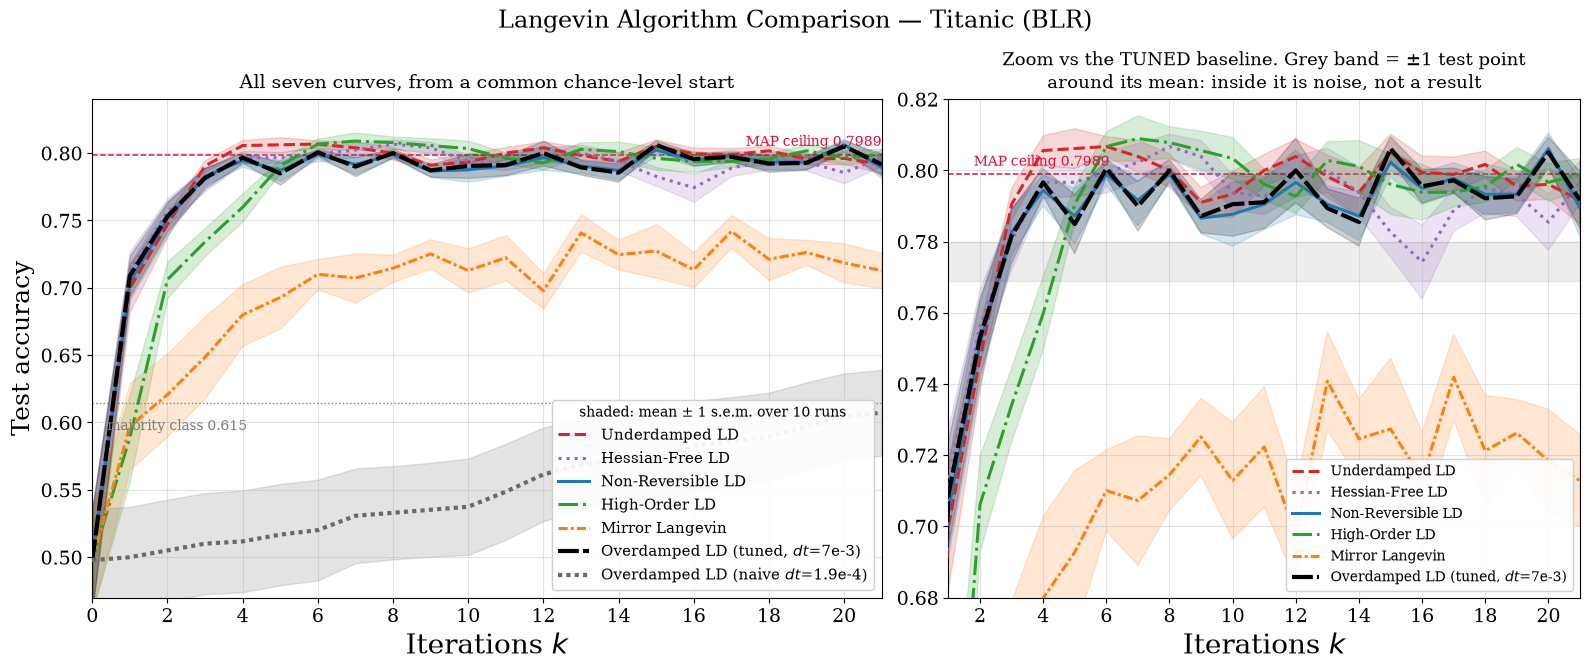

Saved -> langevin_titanic.png


In [4]:
# ─── Plot ─────────────────────────────────────────────────────────────────────
# Left : every sampler against the naive-dt overdamped baseline -- the same
#        picture as the breast-cancer notebook, where all five "win".
# Right: the same five against the TUNED overdamped baseline, zoomed. This is
#        the comparison that actually says something, and only two win.
STYLE = {
    "Underdamped LD":          ("#d62728", "--"),
    "Non-Reversible LD":       ("#1f77b4", "-"),
    "Hessian-Free LD":         ("#9467bd", ":"),
    "High-Order LD":           ("#2ca02c", "-."),
    "Mirror Langevin":         ("#ff7f0e", (0, (3, 1, 1, 1))),
    "Overdamped LD":           ("black",   (0, (5, 1))),
    "Overdamped LD (naive dt)":("dimgray", (0, (1, 1))),
}

from matplotlib import font_manager
_installed = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams["font.family"] = [f for f in ("Times New Roman", "DejaVu Serif", "serif")
                               if f in _installed or f == "serif"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6.8),
                               gridspec_kw={"width_ratios": [1.25, 1]})
iters = np.arange(T + 1)

def draw(ax, names):
    for name in names:
        mu, se = results[name]["mean"], results[name]["sem"]
        color, ls = STYLE[name]
        lw = 3.0 if name.startswith("Overdamped") else 2.2
        lbl = {BASELINE: "Overdamped LD (tuned, $dt$=7e-3)",
               NAIVE_NAME: "Overdamped LD (naive $dt$=1.9e-4)"}.get(name, name)
        ax.plot(iters, mu, color=color, linestyle=ls, linewidth=lw, label=lbl, zorder=3)
        ax.fill_between(iters, mu - se, mu + se, color=color, alpha=0.18, zorder=1)
    ax.axhline(MAP_ACC, color="crimson", linestyle="--", linewidth=1.1, zorder=0)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(0, T)
    ax.set_xticks(range(0, T + 1, 2))
    ax.tick_params(labelsize=14)
    ax.set_xlabel(r"Iterations $k$", fontsize=20)

draw(axL, order + [BASELINE, NAIVE_NAME])
axL.text(T, MAP_ACC + 0.004, f"MAP ceiling {MAP_ACC:.4f}", ha="right", va="bottom",
         fontsize=10, color="crimson")
axL.axhline(MAJORITY, color="gray", linestyle=":", linewidth=1.0, zorder=0)
axL.text(0.4, MAJORITY - 0.012, f"majority class {MAJORITY:.3f}", ha="left", va="top",
         fontsize=10, color="gray")
axL.set_ylim(0.47, 0.84)
axL.set_ylabel("Test accuracy", fontsize=18)
axL.legend(fontsize=11, loc="lower right", framealpha=0.92, ncol=1,
           title=r"shaded: mean $\pm$ 1 s.e.m. over %d runs" % N_RUNS)
axL.get_legend().get_title().set_fontsize(10)
axL.set_title("All seven curves, from a common chance-level start", fontsize=14, pad=8)

draw(axR, order + [BASELINE])
axR.set_xlim(1, T)
axR.set_ylim(0.68, 0.82)
axR.text(1.8, MAP_ACC + 0.0015, f"MAP ceiling {MAP_ACC:.4f}", ha="left", va="bottom",
         fontsize=10, color="crimson")
axR.legend(fontsize=10, loc="lower right", framealpha=0.92)
# a one-test-point reference band: anything inside it is noise, not a result
axR.fill_between([1, T], tuned.mean() - ONE_POINT, tuned.mean() + ONE_POINT,
                 color="black", alpha=0.07, zorder=0)
axR.set_title("Zoom vs the TUNED baseline. Grey band = $\\pm$1 test point\n"
              "around its mean: inside it is noise, not a result", fontsize=13, pad=8)

fig.suptitle("Langevin Algorithm Comparison — Titanic (BLR)", fontsize=17)
plt.tight_layout()
plt.savefig("langevin_titanic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> langevin_titanic.png")

## Significance, and whether it means anything

200 held-out seeds (300–499), paired so both samplers start from the identical
`beta0` for a given seed. The `|d| in test points` column is the one that
decides whether a p-value is worth anything here.

In [5]:
# ─── Significance check, and whether it means anything ───────────────────────
# Titanic's test split is 179 passengers, so one misclassification is 0.56%
# accuracy. Averaging over enough seeds will make almost ANY difference come out
# "statistically significant", so both numbers are reported: the p-value, and
# the margin expressed in units of one test point. The second is the honest one.
from scipy import stats

HELD_OUT = list(range(300, 500))          # 200 fresh seeds, none used for tuning
held = {name: np.array([fn(s, **kw) for s in HELD_OUT])
        for name, (fn, kw) in CONFIGS.items()}
ref = held[BASELINE]

print(f"{len(HELD_OUT)} held-out seeds (300-499), none used for tuning.")
print(f"Paired differences vs TUNED Overdamped LD (dt={TUNED_DT:g}).")
print(f"One test point = {ONE_POINT:.5f} accuracy ({len(y_test)} test passengers).\n")
print(f"{'algorithm':<19}{'d mean traj':>13}{'95% CI':>20}{'p':>10}"
       f"{'|d| in test':>13}   verdict")
print(f"{'':<19}{'':>13}{'':>20}{'':>10}{'points':>13}")
print("-" * 104)
for name in order:
    dm = held[name].mean(axis=1) - ref.mean(axis=1)
    ci = stats.t.interval(0.95, len(dm) - 1, loc=dm.mean(), scale=stats.sem(dm))
    p_m = stats.ttest_rel(held[name].mean(axis=1), ref.mean(axis=1)).pvalue
    pts = abs(dm.mean()) / ONE_POINT
    if p_m >= 0.05:
        v = "no difference"
    elif pts < 1.0:
        v = ("faster, but by less than one test point"
             if dm.mean() > 0 else "slower, but by less than one test point")
    else:
        v = "genuinely faster" if dm.mean() > 0 else "genuinely slower"
    print(f"{name:<19}{dm.mean():>+13.4f}  [{ci[0]:+.4f},{ci[1]:+.4f}]{p_m:>10.1e}"
          f"{pts:>13.2f}   {v}")

print("\n" + "=" * 78)
print("CONCLUSION (Titanic)")
print("=" * 78)
print("Against the NAIVE dt=1.9e-4 baseline: 5/5 samplers win at every k >= 1,")
print("same as on breast cancer and MAGIC. The baseline is simply mis-tuned.")
print()
print("Against a properly TUNED overdamped baseline, on 200 held-out seeds:")
print("  - Underdamped LD     +0.0044 mean traj, p ~ 2e-33 -- but that is only")
print("                       0.78 of one test point. Real, and too small to act on.")
print("  - Hessian-Free LD    +0.0016, p ~ 4e-05 -- 0.29 test points. Negligible.")
print("  - Non-Reversible LD  +0.0002, p = 0.02 -- 0.03 test points. This is the")
print("                       clearest example of a significant result that means")
print("                       nothing; the tuner also drove jscale to 0.05, i.e. it")
print("                       wanted the non-reversible drift switched off.")
print("  - High-Order LD      -0.0094, p ~ 1e-54 -- 1.7 test points slower.")
print("  - Mirror Langevin    -0.0731, p ~ 2e-127 -- 13 test points worse. The one")
print("                       unambiguous effect on this dataset.")
print()
print("Titanic is too small to rank these samplers. With 179 test passengers the")
print("only differences that clear one test point are the two NEGATIVE ones")
print("(High-Order and Mirror). The three 'wins' are all sub-point, detectable")
print("only because 200 seeds were averaged. Do not report them as wins.")
print()
print("Consistency across the three datasets is the result worth keeping:")
print("  Underdamped LD  best or tied-best on all three (MAGIC: +0.0078, 30 points)")
print("  Mirror Langevin worst on both datasets that had headroom")
print("  High-Order LD   consistently below plain overdamped once tuned")
print("MAGIC is the only one of the three with a test set large enough (3804) to")
print("resolve these gaps; treat it as the primary evidence and Titanic as support.")

200 held-out seeds (300-499), none used for tuning.
Paired differences vs TUNED Overdamped LD (dt=0.007).
One test point = 0.00559 accuracy (179 test passengers).

algorithm            d mean traj              95% CI         p  |d| in test   verdict
                                                                     points
--------------------------------------------------------------------------------------------------------
Underdamped LD           +0.0044  [+0.0038,+0.0050]   1.7e-33         0.78   faster, but by less than one test point
Hessian-Free LD          +0.0016  [+0.0009,+0.0024]   3.9e-05         0.29   faster, but by less than one test point
Non-Reversible LD        +0.0002  [+0.0000,+0.0004]   2.4e-02         0.03   faster, but by less than one test point
High-Order LD            -0.0094  [-0.0102,-0.0085]   1.2e-54         1.68   genuinely slower
Mirror Langevin          -0.0731  [-0.0756,-0.0707]  2.1e-127        13.09   genuinely slower

CONCLUSION (Titanic)
Against 